<a href="https://colab.research.google.com/github/LleilaA13/Thesis-MUL/blob/master/resnet18LU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Licensed under the Apache License, Version 2.0 (the "License");

In [ ]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Lucent Modelzoo

A demonstration of how Lucent works with different pretrained models and provides some samples of visualizations on other models.

## Install, Import

In [ ]:
!pip install --quiet git+https://github.com/greentfrapp/lucent.git

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 0model_SA_best.pth.tar to 0model_SA_best.pth.tar


In [ ]:
uploaded = files.upload()

Saving RLcheckpoint.pth.tar to RLcheckpoint.pth.tar


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.resnet import ResNet, BasicBlock

class ResNet18CIFAR10(ResNet):
    def __init__(self, num_classes=10):
        super().__init__(block=BasicBlock, layers=[2, 2, 2, 2], num_classes=num_classes)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.maxpool = nn.Identity()  # Remove maxpool for CIFAR


In [ ]:
import torch

from lucent.optvis import render, param, transform, objectives
from lucent.modelzoo.util import get_model_layers
import torchvision.models as models

def load_model(path, map_location='cuda'):
    model = ResNet18CIFAR10(num_classes=10).to(map_location)
    checkpoint = torch.load(path, map_location=map_location, weights_only=False)

    if 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    # Strip unwanted keys
    filtered_state_dict = {k: v for k, v in state_dict.items() if not k.startswith("normalize")}

    model.load_state_dict(filtered_state_dict, strict=False)
    model.eval()
    return model

In [ ]:
original_model = load_model("0model_SA_best.pth.tar")
unlearned_model = load_model("RLcheckpoint.pth.tar")


In [ ]:
model = original_model


In [ ]:
from lucent.modelzoo.util import get_model_layers
from lucent.optvis import render, param, transform

print("Available layers in the model:")
print(get_model_layers(model))

Available layers in the model:
['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer1_0', 'layer1_0_conv1', 'layer1_0_bn1', 'layer1_0_relu', 'layer1_0_conv2', 'layer1_0_bn2', 'layer1_1', 'layer1_1_conv1', 'layer1_1_bn1', 'layer1_1_relu', 'layer1_1_conv2', 'layer1_1_bn2', 'layer2', 'layer2_0', 'layer2_0_conv1', 'layer2_0_bn1', 'layer2_0_relu', 'layer2_0_conv2', 'layer2_0_bn2', 'layer2_0_downsample', 'layer2_0_downsample_0', 'layer2_0_downsample_1', 'layer2_1', 'layer2_1_conv1', 'layer2_1_bn1', 'layer2_1_relu', 'layer2_1_conv2', 'layer2_1_bn2', 'layer3', 'layer3_0', 'layer3_0_conv1', 'layer3_0_bn1', 'layer3_0_relu', 'layer3_0_conv2', 'layer3_0_bn2', 'layer3_0_downsample', 'layer3_0_downsample_0', 'layer3_0_downsample_1', 'layer3_1', 'layer3_1_conv1', 'layer3_1_bn1', 'layer3_1_relu', 'layer3_1_conv2', 'layer3_1_bn2', 'layer4', 'layer4_0', 'layer4_0_conv1', 'layer4_0_bn1', 'layer4_0_relu', 'layer4_0_conv2', 'layer4_0_bn2', 'layer4_0_downsample', 'layer4_0_downsample_0', 'layer4_0_downsample

100%|██████████| 512/512 [00:20<00:00, 24.41it/s]



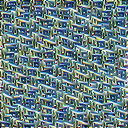

In [ ]:
_ = render.render_vis(model, "layer3_1_conv2:10", show_inline=True)

In [ ]:
model = unlearned_model


In [ ]:
from lucent.modelzoo.util import get_model_layers
from lucent.optvis import render, param, transform

print("Available layers in the model:")
print(get_model_layers(model))


Available layers in the model:
['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer1_0', 'layer1_0_conv1', 'layer1_0_bn1', 'layer1_0_relu', 'layer1_0_conv2', 'layer1_0_bn2', 'layer1_1', 'layer1_1_conv1', 'layer1_1_bn1', 'layer1_1_relu', 'layer1_1_conv2', 'layer1_1_bn2', 'layer2', 'layer2_0', 'layer2_0_conv1', 'layer2_0_bn1', 'layer2_0_relu', 'layer2_0_conv2', 'layer2_0_bn2', 'layer2_0_downsample', 'layer2_0_downsample_0', 'layer2_0_downsample_1', 'layer2_1', 'layer2_1_conv1', 'layer2_1_bn1', 'layer2_1_relu', 'layer2_1_conv2', 'layer2_1_bn2', 'layer3', 'layer3_0', 'layer3_0_conv1', 'layer3_0_bn1', 'layer3_0_relu', 'layer3_0_conv2', 'layer3_0_bn2', 'layer3_0_downsample', 'layer3_0_downsample_0', 'layer3_0_downsample_1', 'layer3_1', 'layer3_1_conv1', 'layer3_1_bn1', 'layer3_1_relu', 'layer3_1_conv2', 'layer3_1_bn2', 'layer4', 'layer4_0', 'layer4_0_conv1', 'layer4_0_bn1', 'layer4_0_relu', 'layer4_0_conv2', 'layer4_0_bn2', 'layer4_0_downsample', 'layer4_0_downsample_0', 'layer4_0_downsample

100%|██████████| 512/512 [00:20<00:00, 25.06it/s]



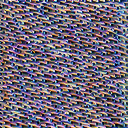

In [ ]:
_ = render.render_vis(model, "layer3_1_conv2:10", show_inline=True)